In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("../data/employee_financial_health.csv")

In [29]:
df.shape

(10000, 20)

In [30]:
df.head()

,EmployeeID,EmployeeName,Age,Years_of_Experience,Department,Monthly_Salary,Income_Tax,PF_Contribution,Insurance_Deduction,Other_Deductions,Net_Salary,Rent_Expense,Grocery_Expense,EMI_or_Loan_Payment,Entertainment_Expense,Other_Expenses,Total_Expenditure,Savings_Amount,Investments,Class
0,EMP00001,Gaurav Akash Chauhan,29,2,Marketing,55811,1124,3349,744,1183,49411,0,4829,0,4310,2085,11224,16741,4953,High
1,EMP00002,Vivek Aman Nagpal,49,20,Cyber Security,152405,13814,9144,3436,1697,124314,0,21752,40587,4688,8564,75591,223,553,Low
2,EMP00003,Amit Bhardwaj,40,9,Operations,67086,1709,4025,1366,1399,58587,0,8860,12984,1814,2721,26379,2980,1006,Low
3,EMP00004,Avantika Arora,25,1,Operations,51199,893,3072,1148,1563,44523,8650,3968,4732,2982,2072,22404,12826,1598,Medium
4,EMP00005,Reema Patel,30,6,Sales,51015,884,3061,1105,1294,44671,10748,7543,0,2268,2825,23384,9848,2595,Medium


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   EmployeeID             10000 non-null  object
 1   EmployeeName           10000 non-null  object
 2   Age                    10000 non-null  int64 
 3   Years_of_Experience    10000 non-null  int64 
 4   Department             10000 non-null  object
 5   Monthly_Salary         10000 non-null  int64 
 6   Income_Tax             10000 non-null  int64 
 7   PF_Contribution        10000 non-null  int64 
 8   Insurance_Deduction    10000 non-null  int64 
 9   Other_Deductions       10000 non-null  int64 
 10  Net_Salary             10000 non-null  int64 
 11  Rent_Expense           10000 non-null  int64 
 12  Grocery_Expense        10000 non-null  int64 
 13  EMI_or_Loan_Payment    10000 non-null  int64 
 14  Entertainment_Expense  10000 non-null  int64 
 15  Other_Expenses      

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,41.0804,11.228363,22.0,31.00,41.0,51.00,60.0
Years_of_Experience,10000.0,16.7165,10.825463,0.0,7.00,16.0,26.00,38.0
Monthly_Salary,10000.0,93614.5582,37411.532969,35000.0,63452.25,85000.0,118171.00,220000.0
Income_Tax,10000.0,5429.0031,5326.882688,83.0,1505.75,3500.0,7725.50,31000.0
PF_Contribution,10000.0,5616.8740,2244.695529,2100.0,3807.50,5100.0,7090.50,13200.0
Insurance_Deduction,10000.0,2015.6549,890.419823,700.0,1300.00,1845.0,2644.25,3999.0
Other_Deductions,10000.0,1598.2709,386.144255,623.0,1293.00,1596.0,1896.00,2551.0
Net_Salary,10000.0,78954.7553,29299.710014,29547.0,54876.25,73642.5,98577.25,172213.0
Rent_Expense,10000.0,8874.9699,10499.495391,0.0,0.00,4171.0,16605.75,55308.0
Grocery_Expense,10000.0,11303.5601,4790.763206,2262.0,7724.75,10520.5,13945.75,31615.0


In [33]:
df.isnull().sum()

EmployeeID               0
EmployeeName             0
Age                      0
Years_of_Experience      0
Department               0
Monthly_Salary           0
Income_Tax               0
PF_Contribution          0
Insurance_Deduction      0
Other_Deductions         0
Net_Salary               0
Rent_Expense             0
Grocery_Expense          0
EMI_or_Loan_Payment      0
Entertainment_Expense    0
Other_Expenses           0
Total_Expenditure        0
Savings_Amount           0
Investments              0
Class                    0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df["EmployeeID"].duplicated().sum()

np.int64(0)

In [36]:
(df["Net_Salary"] > df["Monthly_Salary"]).sum()

np.int64(0)

In [37]:
deductions = (

    df["Income_Tax"] + df["PF_Contribution"] + df["Insurance_Deduction"] + df["Other_Deductions"]

)

(df["Monthly_Salary"] - deductions != df["Net_Salary"]).sum()

np.int64(0)

In [38]:
(df["Total_Expenditure"]>df["Net_Salary"]).sum()

np.int64(14)

In [39]:
remaining = (df["Net_Salary"]-df["Total_Expenditure"])

(df["Savings_Amount"]>remaining).sum()

np.int64(14)

In [40]:
numeric = df.select_dtypes(include=np.number)

(numeric < 0).sum()

Age                      0
Years_of_Experience      0
Monthly_Salary           0
Income_Tax               0
PF_Contribution          0
Insurance_Deduction      0
Other_Deductions         0
Net_Salary               0
Rent_Expense             0
Grocery_Expense          0
EMI_or_Loan_Payment      0
Entertainment_Expense    0
Other_Expenses           0
Total_Expenditure        0
Savings_Amount           0
Investments              0
dtype: int64

<Axes: xlabel='Monthly_Salary', ylabel='Count'>

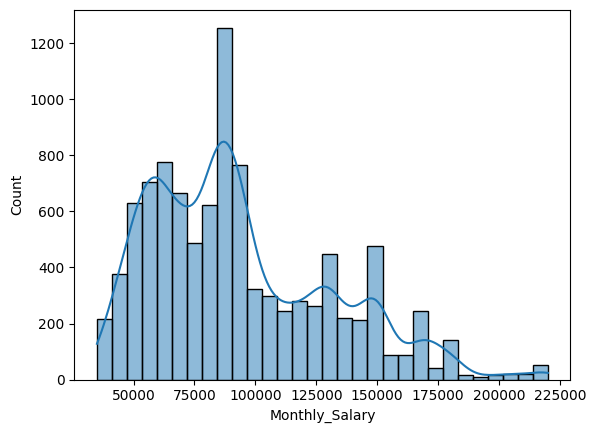

In [41]:
sns.histplot(
    df["Monthly_Salary"],
    bins=30,
    kde=True
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Marketing'),
  Text(1, 0, 'Cyber Security'),
  Text(2, 0, 'Operations'),
  Text(3, 0, 'Sales'),
  Text(4, 0, 'IT'),
  Text(5, 0, 'Finance'),
  Text(6, 0, 'HR'),
  Text(7, 0, 'Customer Support'),
  Text(8, 0, 'Product Management'),
  Text(9, 0, 'Data Science')])

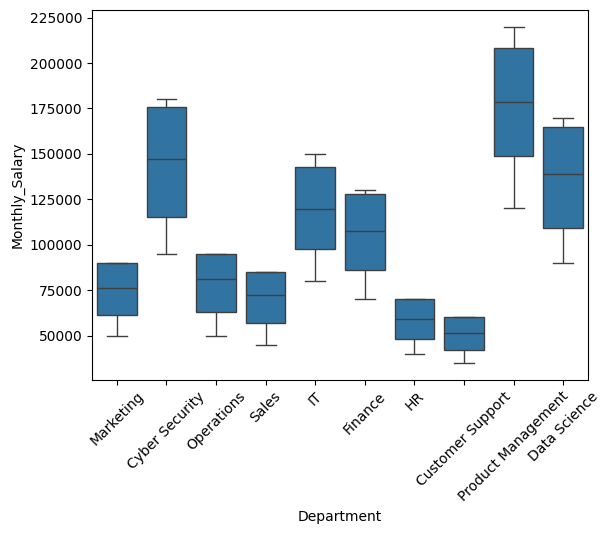

In [42]:
sns.boxplot(

    data=df,

    x="Department",

    y="Monthly_Salary"

)

plt.xticks(rotation=45)

<Axes: xlabel='Age', ylabel='Count'>

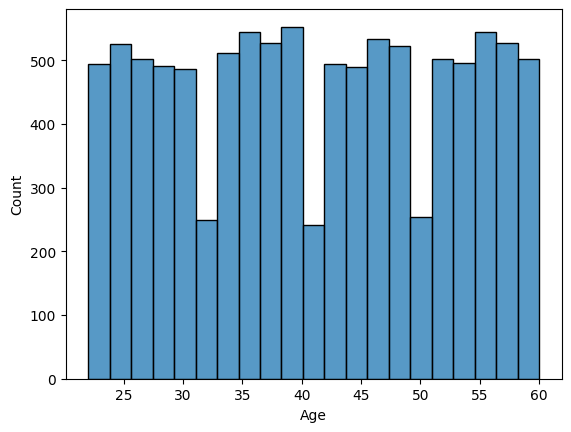

In [43]:
sns.histplot(df["Age"])

<Axes: xlabel='Years_of_Experience', ylabel='Count'>

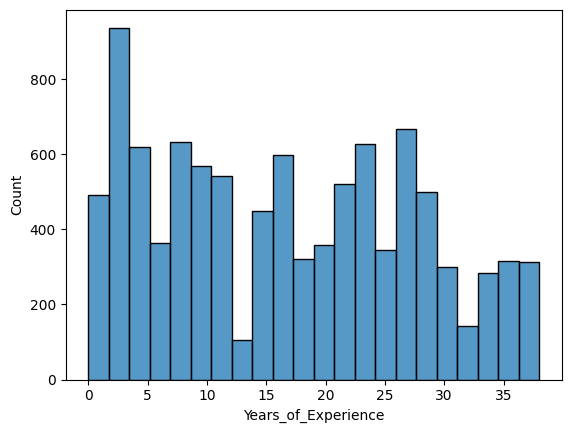

In [44]:
sns.histplot(
    df["Years_of_Experience"]
)

<Axes: xlabel='Age', ylabel='Years_of_Experience'>

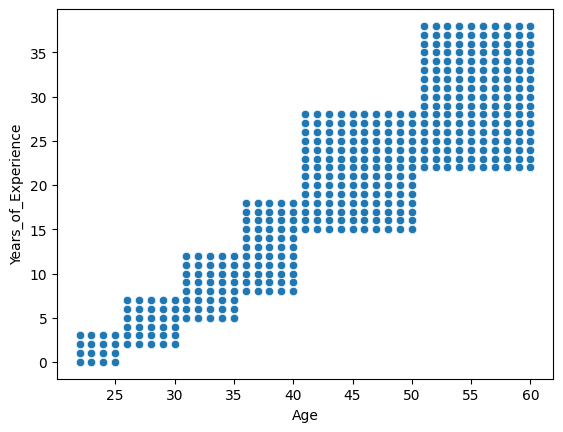

In [45]:
sns.scatterplot(

    data=df,

    x="Age",

    y="Years_of_Experience"

)

In [46]:
df["Expense_Ratio"] = (

    df["Total_Expenditure"]

    /

    df["Net_Salary"]

)

In [47]:
df["Expense_Ratio"].describe()

count    10000.000000
mean         0.499888
std          0.145904
min          0.156500
25%          0.410653
50%          0.507303
75%          0.590422
max          1.057149
Name: Expense_Ratio, dtype: float64

In [48]:
df["Savings_Ratio"] = (

    df["Savings_Amount"]

    /

    df["Net_Salary"]

)

In [49]:
df["Investment_Ratio"] = (

    df["Investments"]

    /

    df["Net_Salary"]

)

In [50]:
df["EMI_Ratio"] = (

    df["EMI_or_Loan_Payment"]

    /

    df["Net_Salary"]

)

In [51]:
df[
    [
        "Expense_Ratio",
        "Savings_Ratio",
        "Investment_Ratio",
        "EMI_Ratio"
    ]
].describe()

,Expense_Ratio,Savings_Ratio,Investment_Ratio,EMI_Ratio
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.499888,0.181613,0.062879,0.108484
std,0.145904,0.121643,0.054958,0.118561
min,0.156500,0.000000,0.000000,0.000000
25%,0.410653,0.068246,0.035023,0.000000
50%,0.507303,0.175760,0.049002,0.061884
75%,0.590422,0.265102,0.066560,0.213865
max,1.057149,0.580464,0.363259,0.450003


In [52]:
df.to_csv(
    "validated_employee_financial_health.csv",
    index=False
)